# TSMC → Foursquare Open Places (FSQ-OS) Matching Pipeline

Goal: for each POI (`venue_id`) in the TSMC2014 checkin dataset, find a matching
record in the Foursquare Open Places dataset so we can build a text description
for the diffusion-LM (LLaDA) input.

Steps:
1. Load & preprocess TSMC2014 checkins → get the set of venue IDs we need (`nyc_ids`)
2. Match against the **latest** FSQ-OS release
3. **Fallback**: for anything still unmatched, walk backwards through older FSQ-OS
   releases (venue IDs sometimes get deprecated/merged over time, so an older
   snapshot can still contain them) until everything is matched or releases run out
4. Merge all matches, report final coverage, build text descriptions


## 0. Setup

In [1]:
import os
import re
import multiprocessing as mp

import duckdb
import pandas as pd
import pyarrow.parquet as pq
from huggingface_hub import login, list_repo_files, hf_hub_download


In [2]:
# --- Config -----------------------------------------------------
DATASET      = "NYC"   # "NYC" or "TKY" -- just changes RAW_FILE below
RAW_FILE     = f"/kaggle/input/datasets/yosrkharrat/tsmc2014/dataset_TSMC2014_NYC.txt"
OUTPUT_DIR   = "/kaggle/working"

MIN_VENUE_VISITS = 10
MIN_USER_VISITS  = 30

FSQ_REPO       = "foursquare/fsq-os-places"
FSQ_KEEP_COLS  = ["fsq_place_id", "name", "fsq_category_labels", "address", "locality", "region"]
FSQ_TMP_DIR    = "/kaggle/working/fsq_tmp"
NUM_WORKERS    = min(mp.cpu_count(), 4)
MAX_FALLBACK_RELEASES = 5   # safety cap: how many older releases to try before giving up


In [3]:
# --- HF auth ------------------------------------------------------
# Never hardcode tokens in a notebook. Set HF_TOKEN as an env var / Kaggle secret instead.
from kaggle_secrets import UserSecretsClient


hf_token =  UserSecretsClient().get_secret("HF_TOKEN")
if not hf_token:
    raise RuntimeError("Set the HF_TOKEN environment variable (or a Kaggle secret) before running this cell.")
login(token=hf_token)


## 1. Load & preprocess TSMC2014 checkins

In [4]:
df = pd.read_csv(
    RAW_FILE,
    sep="\t",
    header=None,
    names=[
        "user_id",
        "venue_id",
        "venue_category_id",
        "venue_category_name",
        "latitude",
        "longitude",
        "timezone_offset",
        "utc_time",
    ],
    encoding="latin-1",
)

df["utc_time"] = pd.to_datetime(df["utc_time"], format="%a %b %d %H:%M:%S +0000 %Y", utc=True)

print(f"Raw rows     : {len(df):,}")
print(f"Unique users : {df['user_id'].nunique():,}")
print(f"Unique venues: {df['venue_id'].nunique():,}")
print(f"Date range   : {df['utc_time'].min().date()} → {df['utc_time'].max().date()}")


Raw rows     : 227,428
Unique users : 1,083
Unique venues: 38,333
Date range   : 2012-04-03 → 2013-02-16


In [5]:
# Remove low-frequency POIs and users
venue_counts = df["venue_id"].value_counts()
valid_venues = venue_counts[venue_counts >= MIN_VENUE_VISITS].index
df = df[df["venue_id"].isin(valid_venues)]
print(f"After POI filter (>={MIN_VENUE_VISITS} visits) : {len(df):,} rows, {df['venue_id'].nunique():,} venues")

user_counts = df["user_id"].value_counts()
valid_users = user_counts[user_counts >= MIN_USER_VISITS].index
df = df[df["user_id"].isin(valid_users)]
print(f"After user filter (>={MIN_USER_VISITS} visits) : {len(df):,} rows, {df['user_id'].nunique():,} users")


After POI filter (>=10 visits) : 147,938 rows, 5,135 venues
After user filter (>=30 visits) : 147,699 rows, 1,073 users


In [6]:
# Chronological 80/10/10 split per user
train_rows, val_rows, test_rows = [], [], []

for user_id, user_df in df.groupby("user_id"):
    user_df = user_df.sort_values("utc_time").reset_index(drop=True)
    n       = len(user_df)
    n_train = int(n * 0.80)
    n_val   = int(n * 0.90)

    train_rows.append(user_df.iloc[:n_train])
    val_rows.append(user_df.iloc[n_train:n_val])
    test_rows.append(user_df.iloc[n_val:])

train_df = pd.concat(train_rows, ignore_index=True)
val_df   = pd.concat(val_rows,   ignore_index=True)
test_df  = pd.concat(test_rows,  ignore_index=True)

# Keep only users/venues seen in train
train_venues = set(train_df["venue_id"])
train_users  = set(train_df["user_id"])

val_df  = val_df[val_df["venue_id"].isin(train_venues)  & val_df["user_id"].isin(train_users)].reset_index(drop=True)
test_df = test_df[test_df["venue_id"].isin(train_venues) & test_df["user_id"].isin(train_users)].reset_index(drop=True)

print(f"Train : {len(train_df):,} rows | {train_df['user_id'].nunique():,} users | {train_df['venue_id'].nunique():,} venues")
print(f"Val   : {len(val_df):,}   rows | {val_df['user_id'].nunique():,} users | {val_df['venue_id'].nunique():,} venues")
print(f"Test  : {len(test_df):,}  rows | {test_df['user_id'].nunique():,} users | {test_df['venue_id'].nunique():,} venues")


Train : 117,736 rows | 1,073 users | 5,120 venues
Val   : 14,657   rows | 1,073 users | 4,045 venues
Test  : 15,146  rows | 1,073 users | 3,954 venues


In [7]:
# venue_id -> poi_idx mapping (based on train vocabulary only)
target_ids = set(train_df["venue_id"].unique())

sorted_venues = sorted(target_ids)
venue_to_idx  = {v: i for i, v in enumerate(sorted_venues)}
idx_to_venue  = {i: v for v, i in venue_to_idx.items()}

for split in (train_df, val_df, test_df):
    split["poi_idx"] = split["venue_id"].map(venue_to_idx)

print(f"POI index range: poi_0 → poi_{len(venue_to_idx)-1}  ({len(target_ids):,} venues total)")


POI index range: poi_0 → poi_5119  (5,120 venues total)


## 2. Discover FSQ-OS releases

Foursquare publishes a new Open Places snapshot roughly monthly. We list all
available releases (newest → oldest) so we know what's available for the
fallback pass later.

In [8]:
con = duckdb.connect()

releases = con.execute("""
    SELECT DISTINCT regexp_extract(file, 'dt=([0-9-]+)', 1) AS dt
    FROM glob('hf://datasets/foursquare/fsq-os-places/release/**')
    ORDER BY dt DESC
""").df()

release_dates = releases["dt"].tolist()
print(f"{len(release_dates)} releases found. Newest: {release_dates[0]}  Oldest: {release_dates[-1]}")


19 releases found. Newest: 2026-06-11  Oldest: 2024-12-03


## 3. Matching helper

Downloads one parquet shard, keeps only rows whose `fsq_place_id` is in our target set, then deletes the local copy.

In [9]:
def process_file(filename: str, target_ids: set) -> pd.DataFrame:
    local_path = hf_hub_download(
        repo_id=FSQ_REPO,
        repo_type="dataset",
        filename=filename,
        local_dir=FSQ_TMP_DIR,
    )
    table = pq.read_table(local_path, columns=FSQ_KEEP_COLS)
    matched = table.to_pandas()
    matched = matched[matched["fsq_place_id"].isin(target_ids)]

    os.remove(local_path)
    return matched


def match_release(dt: str, target_ids: set, all_files: list[str]) -> pd.DataFrame:
    """Match target_ids against a single FSQ-OS release date."""
    prefix = f"release/dt={dt}/places/parquet/"
    files = sorted(f for f in all_files if f.startswith(prefix) and f.endswith(".parquet"))
    if not files:
        return pd.DataFrame(columns=FSQ_KEEP_COLS)

    with mp.Pool(NUM_WORKERS) as pool:
        results = pool.starmap(process_file, [(f, target_ids) for f in files])

    matched = pd.concat(results, ignore_index=True) if results else pd.DataFrame(columns=FSQ_KEEP_COLS)
    matched = matched.rename(columns={"fsq_place_id": "venue_id"})
    return matched


## 4. Primary match — latest release

In [10]:
all_files = list_repo_files(FSQ_REPO, repo_type="dataset")

latest_dt = release_dates[0]
fsq_df = match_release(latest_dt, target_ids, all_files)

matched_ids   = set(fsq_df["venue_id"])
unmatched_ids = target_ids - matched_ids

print(f"Release {latest_dt}: matched {len(matched_ids):,} / {len(target_ids):,} "
      f"({len(matched_ids)/len(target_ids):.1%})")
print(f"Still unmatched: {len(unmatched_ids):,}")


Release 2026-06-11: matched 4,457 / 5,120 (87.1%)
Still unmatched: 663


In [11]:
# Sanity checks
print(fsq_df.isnull().sum())
print("Duplicate venue_ids:", fsq_df["venue_id"].duplicated().sum())


venue_id                 0
name                     0
fsq_category_labels      0
address                374
locality                42
region                  26
dtype: int64
Duplicate venue_ids: 0


## 6. Handle any remaining unmatched venues

Decide a policy rather than silently dropping them: here we keep them with a
placeholder description built from the checkin data's own category label
(`venue_category_name`) so the POI vocabulary doesn't shrink further.

In [12]:
if unmatched_ids:
    fallback_meta = (
        df[df["venue_id"].isin(unmatched_ids)]
        [["venue_id", "venue_category_name", "latitude", "longitude"]]
        .drop_duplicates(subset="venue_id")
    )
    fallback_meta["name"] = None
    fallback_meta["fsq_category_labels"] = None
    fallback_meta["address"] = None
    fallback_meta["locality"] = None
    fallback_meta["region"] = None
    fallback_meta["category"] = fallback_meta["venue_category_name"]
    fallback_meta["description"] = fallback_meta["category"].apply(
        lambda c: f"A {c} venue." if pd.notna(c) else "A point of interest."
    )
    print(f"Built placeholder descriptions for {len(fallback_meta):,} still-unmatched venues.")
else:
    fallback_meta = pd.DataFrame(columns=["venue_id", "category", "description"])


Built placeholder descriptions for 663 still-unmatched venues.


## 7. Build text descriptions for matched venues

In [13]:
def extract_category(labels):
    """fsq_category_labels is a list of category-path lists, e.g. [[\"Food\", \"Restaurant\", \"American Restaurant\"]].
    Take the *full* most specific path (first path), joined as "Food > Restaurant > American Restaurant"
    -- not just the leaf -- since Stage 1 (SUBCATEGORY_OF edges) and the taxonomy-depth
    sanity check in Section 9.5 both need the full chain, not the last element alone.

    NOTE: pyarrow/pandas often materializes this column's values as numpy
    arrays (not plain python lists), so `if not labels:` blows up with
    "The truth value of an array with more than one element is ambiguous."
    We check length explicitly instead of relying on truthiness."""
    if labels is None:
        return None
    if len(labels) == 0:
        return None
    first = labels[0]
    if isinstance(first, str):
        return first
    if hasattr(first, "__len__") and len(first) > 0:
        return " > ".join(str(p) for p in first)
    return None


def build_description(row):
    name     = row.get("name")     if pd.notna(row.get("name"))     else None
    category = row.get("category") if pd.notna(row.get("category")) else None
    address  = row.get("address")  if pd.notna(row.get("address"))  else None
    locality = row.get("locality") if pd.notna(row.get("locality")) else None
    region   = row.get("region")   if pd.notna(row.get("region"))   else None

    if not name:
        return None

    location_parts = [p for p in (address, locality, region) if p]
    location_str    = ", ".join(location_parts) if location_parts else None

    if category and location_str:
        return f"{name} is a {category} located at {location_str}."
    elif category:
        return f"{name} is a {category}."
    elif location_str:
        return f"{name} is located at {location_str}."
    else:
        return f"{name}."


fsq_df["category"]    = fsq_df["fsq_category_labels"].apply(extract_category)
fsq_df["description"] = fsq_df.apply(build_description, axis=1)

print(f"Built descriptions for {fsq_df['description'].notna().sum():,} / {len(fsq_df):,} matched venues")


Built descriptions for 4,457 / 4,457 matched venues


In [14]:
print("Sample descriptions:")
for _, r in fsq_df[["venue_id", "description"]].dropna().head(5).iterrows():
    print(f"  {r['venue_id']} → {r['description']}")

print("\nSample category chains (should show full path, e.g. 'Dining and Drinking > Bar'):")
print(fsq_df["category"].dropna().sample(min(5, fsq_df["category"].notna().sum()), random_state=0).tolist())


Sample descriptions:
  42ec1480f964a5209e261fe3 → Jacob Riis Park is a Landmarks and Outdoors > Beach located at 1 Rockaway Beach Blvd., Rockaway Park, NY.
  4aaa38e9f964a520a15520e3 → Floyd Bennett Field is a Landmarks and Outdoors > Park > National Park located at 1 Aviation Rd, Brooklyn, NY.
  4b3613a9f964a520013025e3 → Aviator Sports & Events Center is a Sports and Recreation > Gym and Studio > Climbing Gym located at 3159 Flatbush Ave, Brooklyn, NY.
  4a40f778f964a520afa41fe3 → Kings Plaza Mall is a Retail > Shopping Mall located at 5100 Kings Plz, Brooklyn, NY.
  4de45c45ae60e7f3ac1d7925 → Panera Bread is a Dining and Drinking > Bakery located at 5158 Kings Plz, Brooklyn, NY.

Sample category chains (should show full path, e.g. 'Dining and Drinking > Bar'):
['Dining and Drinking > Cafe, Coffee, and Tea House > Coffee Shop', 'Retail > Food and Beverage Retail > Supermarket', 'Retail > Computers and Electronics Retail > Electronics Store', 'Dining and Drinking > Restaurant > BBQ Jo

## 8. Combine matched + placeholder, save

In [15]:
poi_coords = (
    train_df.groupby("poi_idx")[["latitude", "longitude"]]
    .mean()
    .reset_index()
)

poi_meta = pd.concat(
    [fsq_df[["venue_id", "name", "category", "locality", "region", "description"]],
     fallback_meta[["venue_id", "category", "description"]]],  # locality/region stay NaN here — expected
    ignore_index=True,
).drop_duplicates(subset="venue_id", keep="first")

poi_meta["poi_idx"] = poi_meta["venue_id"].map(venue_to_idx)
poi_meta = poi_meta.dropna(subset=["poi_idx"]).sort_values("poi_idx").reset_index(drop=True)

poi_meta = poi_meta.merge(poi_coords, on="poi_idx", how="left")  # after poi_idx is assigned, same as now

print(f"Final POI metadata table: {len(poi_meta):,} rows "
      f"(target vocabulary was {len(target_ids):,} venues)")

os.makedirs(OUTPUT_DIR, exist_ok=True)
poi_meta.to_csv(f"{OUTPUT_DIR}/poi_metadata_{DATASET}.csv", index=False)
train_df.to_csv(f"{OUTPUT_DIR}/train_{DATASET}.csv", index=False)
val_df.to_csv(f"{OUTPUT_DIR}/val_{DATASET}.csv", index=False)
test_df.to_csv(f"{OUTPUT_DIR}/test_{DATASET}.csv", index=False)

print("Saved poi_metadata, train, val, test CSVs to", OUTPUT_DIR)


Final POI metadata table: 5,120 rows (target vocabulary was 5,120 venues)
Saved poi_metadata, train, val, test CSVs to /kaggle/working


## 9. Sanity Checks

Reload the saved CSVs from disk (rather than reusing in-memory `df`/`fsq_df`) so this actually catches what got written to disk, and run each check independently per dataset. Set `DATASET` below and re-run for `"NYC"` then `"TKY"` — don't assume the two behave the same.

In [16]:
# --- Reload from disk for sanity checking -------------------------
DATASET    = "NYC"   # run this whole section once for "NYC", once for "TKY"
OUTPUT_DIR = "/kaggle/working"

splits = {}
for _name in ["train", "val", "test"]:
    _path = f"{OUTPUT_DIR}/{_name}_{DATASET}.csv"
    if os.path.exists(_path):
        splits[_name] = pd.read_csv(_path)
        print(f"[loaded] {_name}_{DATASET}.csv -> {splits[_name].shape}")
    else:
        print(f"[MISSING] {_path} — checks needing {_name}_df will be skipped")

train_df = splits.get("train")
val_df   = splits.get("val")
test_df  = splits.get("test")

poi_meta = pd.read_csv(f"{OUTPUT_DIR}/poi_metadata_{DATASET}.csv")
print(f"[loaded] poi_metadata_{DATASET}.csv -> {poi_meta.shape}")

[loaded] train_NYC.csv -> (117736, 9)
[loaded] val_NYC.csv -> (14657, 9)
[loaded] test_NYC.csv -> (15146, 9)
[loaded] poi_metadata_NYC.csv -> (5120, 9)


### 9.1 Missing values / nulls

In [17]:
for _name, _d in splits.items():
    print(f"--- {_name}_df.isnull().sum() ---")
    print(_d.isnull().sum())
    print()

print("--- poi_meta.isnull().sum() (post placeholder-merge — concat can reintroduce NaNs, "
      "e.g. 'name' is dropped in fallback_meta's selected columns) ---")
print(poi_meta.isnull().sum())
print()
print("description.isna().sum():", poi_meta['description'].isna().sum(),
      "(should be 0 — fallback branch guarantees a string)")

# poi_idx dropna row-count check — confirm dropna(subset=['poi_idx']) didn't silently
# drop rows that shouldn't have been dropped
_before = len(poi_meta)
_after  = len(poi_meta.dropna(subset=['poi_idx']))
print(f"poi_idx dropna: {_before:,} -> {_after:,} rows (dropped {_before - _after:,})")


print("locality null:", poi_meta['locality'].isna().sum(), "/", len(poi_meta))
print("lat/lon null:", poi_meta[['latitude','longitude']].isna().any(axis=1).sum(), "/", len(poi_meta))


--- train_df.isnull().sum() ---
user_id                0
venue_id               0
venue_category_id      0
venue_category_name    0
latitude               0
longitude              0
timezone_offset        0
utc_time               0
poi_idx                0
dtype: int64

--- val_df.isnull().sum() ---
user_id                0
venue_id               0
venue_category_id      0
venue_category_name    0
latitude               0
longitude              0
timezone_offset        0
utc_time               0
poi_idx                0
dtype: int64

--- test_df.isnull().sum() ---
user_id                0
venue_id               0
venue_category_id      0
venue_category_name    0
latitude               0
longitude              0
timezone_offset        0
utc_time               0
poi_idx                0
dtype: int64

--- poi_meta.isnull().sum() (post placeholder-merge — concat can reintroduce NaNs, e.g. 'name' is dropped in fallback_meta's selected columns) ---
venue_id         0
name           663
categ

### 9.2 Duplicates / integrity

In [18]:
print("poi_meta['venue_id'].duplicated().sum():", poi_meta['venue_id'].duplicated().sum(),
      "(should be 0)")
print("poi_meta['poi_idx'].duplicated().sum():   ", poi_meta['poi_idx'].duplicated().sum(),
      "(should be 0 — a dup here means two POIs share an embedding row)")

_no_gaps = set(poi_meta['poi_idx'].astype(int)) == set(range(len(poi_meta)))
print("poi_idx range has no gaps:", _no_gaps,
      "(vocabulary-extension token-ID math depends on this)")

_dup_desc = poi_meta['description'].duplicated().sum()
print(f"poi_meta['description'].duplicated().sum(): {_dup_desc}")
if _dup_desc:
    _dupes = poi_meta[poi_meta['description'].duplicated(keep=False)].sort_values('description')
    print(f"  -> {_dup_desc} POIs share a description with >=1 other POI — inspect a sample:")
    print(_dupes[['venue_id', 'name', 'description']].head(10).to_string(index=False))
    # Flag: are these genuine chain-store collisions (disambiguation risk) or just the
    # generic 'A <category> venue.' fallback template? Split it out:
    _generic = _dupes['description'].str.match(r'^A .+ venue\.$')
    print(f"  -> of which {_generic.sum()} are the generic fallback template, "
          f"{len(_dupes) - _generic.sum()} are real named-venue collisions")


poi_meta['venue_id'].duplicated().sum(): 0 (should be 0)
poi_meta['poi_idx'].duplicated().sum():    0 (should be 0 — a dup here means two POIs share an embedding row)
poi_idx range has no gaps: True (vocabulary-extension token-ID math depends on this)
poi_meta['description'].duplicated().sum(): 590
  -> 590 POIs share a description with >=1 other POI — inspect a sample:
                venue_id name                  description
4a45652cf964a52021a81fe3  NaN             A Airport venue.
4dadfa8d4df0f639f24297c5  NaN             A Airport venue.
501ec2b2e4b0abe6106743a7  NaN A American Restaurant venue.
4f3020f6e4b007725d366bf1  NaN A American Restaurant venue.
4ef5336e8b812e39d6708644  NaN              A Arcade venue.
4e80010cf9f4c8c37f4c9ae7  NaN              A Arcade venue.
4f6d0488e4b07fa2c54d2cc4  NaN     A Automotive Shop venue.
4c00297392a6c9280cc243e2  NaN     A Automotive Shop venue.
4f555da0e4b0b1295c78126c  NaN                 A Bar venue.
4f44429ce4b0f1d45ca8af2b  NaN        

### 9.3 Cross-file consistency

In [19]:
if train_df is not None and val_df is not None and test_df is not None:
    _split_idx = set(train_df['poi_idx']) | set(val_df['poi_idx']) | set(test_df['poi_idx'])
    _meta_idx  = set(poi_meta['poi_idx'])
    _missing   = _split_idx - _meta_idx
    print("split poi_idx subset of poi_meta poi_idx:", _split_idx.issubset(_meta_idx))
    if _missing:
        print(f"  -> {len(_missing)} poi_idx values used in a split have NO metadata row "
              f"(embedding lookup will fail at train time): {sorted(_missing)[:10]}...")

    _val_min  = val_df.groupby('user_id').size().min()
    _test_min = test_df.groupby('user_id').size().min()
    print(f"val_df min sequence length per user:  {_val_min}")
    print(f"test_df min sequence length per user: {_test_min}")
    if _val_min == 0 or _test_min == 0:
        print("  -> WARNING: at least one user has an empty val/test sequence after "
              "train-vocab filtering")
else:
    print("Skipped: need train_/val_/test_ CSVs all present for this dataset. "
          f"Currently have: {list(splits.keys())}")


split poi_idx subset of poi_meta poi_idx: True
val_df min sequence length per user:  3
test_df min sequence length per user: 3


### 9.4 Language / encoding

In [20]:
_jp_pattern = r'[\u3040-\u30ff\u4e00-\u9fff]'
_jp_hits = poi_meta['description'].astype(str).str.contains(_jp_pattern, regex=True)
print("Descriptions still containing JP/Han-range chars:", _jp_hits.sum(),
      "(should be 0 post-translation)")
if _jp_hits.sum():
    print(poi_meta.loc[_jp_hits, ['venue_id', 'name', 'description']].to_string(index=False))
    print("\nNOTE: \\u4e00-\\u9fff is the shared CJK Unified Ideographs block, so this also "
          "flags Chinese characters (e.g. Chinese restaurant/business names), not just "
          "untranslated Japanese. Spot-check each hit manually before assuming it's a "
          "translation miss rather than a legitimate bilingual venue name.")


Descriptions still containing JP/Han-range chars: 3 (should be 0 post-translation)
                venue_id                       name                                                                                                                                                             description
3fd66200f964a52067e61ee3         Joe's Shanghai 鹿嗚春                                    Joe's Shanghai 鹿嗚春 is a Dining and Drinking > Restaurant > Asian Restaurant > Chinese Restaurant located at 9 Pell St, New York, NY.
3fd66200f964a520d5e31ee3 Jing Fong Restaurant 金豐大酒樓 Jing Fong Restaurant 金豐大酒樓 is a Dining and Drinking > Restaurant > Asian Restaurant > Chinese Restaurant > Dim Sum Restaurant located at 20 Elizabeth St, New York, NY.
4b53672bf964a520199b27e3 Great Wall Supermarket 大中華                                          Great Wall Supermarket 大中華 is a Retail > Food and Beverage Retail > Supermarket located at 137-45 Northern Blvd, Flushing, NY.

NOTE: \u4e00-\u9fff is the shared CJ

### 9.5 Distribution checks

config.json: 0.00B [00:00, ?B/s]

configuration_llada.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/GSAI-ML/LLaDA-8B-Instruct:
- configuration_llada.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

count    5120.000000
mean       26.574023
std         9.192520
min         4.000000
25%        24.000000
50%        29.000000
75%        32.000000
max        82.000000
Name: description, dtype: float64


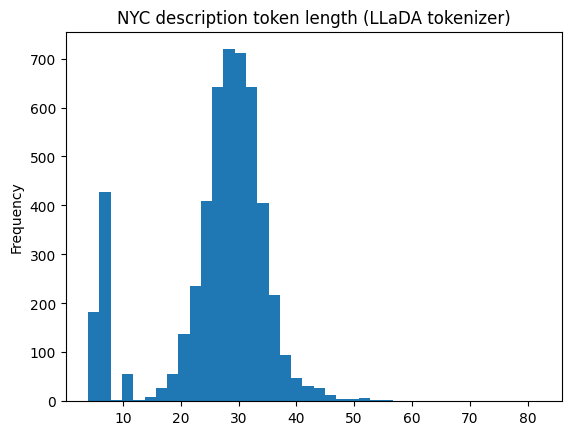

In [21]:
# Token length under LLaDA's tokenizer -- requires network/HF access (run on Kaggle).
try:
    from transformers import AutoTokenizer
    _tok = AutoTokenizer.from_pretrained("GSAI-ML/LLaDA-8B-Instruct", trust_remote_code=True)
    _lens = poi_meta['description'].apply(lambda s: len(_tok.encode(s)))
    print(_lens.describe())
    _lens.plot(kind='hist', bins=40, title=f'{DATASET} description token length (LLaDA tokenizer)')
except Exception as e:
    print(f"Tokenizer check skipped ({e}). Falling back to whitespace word-count as a rough proxy:")
    _wc = poi_meta['description'].str.split().str.len()
    print(_wc.describe())
    _wc.plot(kind='hist', bins=40, title=f'{DATASET} description word count (proxy, not real tokens)')


category taxonomy depth value counts:
category
1     696
2    1588
3    2431
4     384
5      21
Name: count, dtype: int64


<Axes: title={'center': 'NYC category taxonomy depth'}>

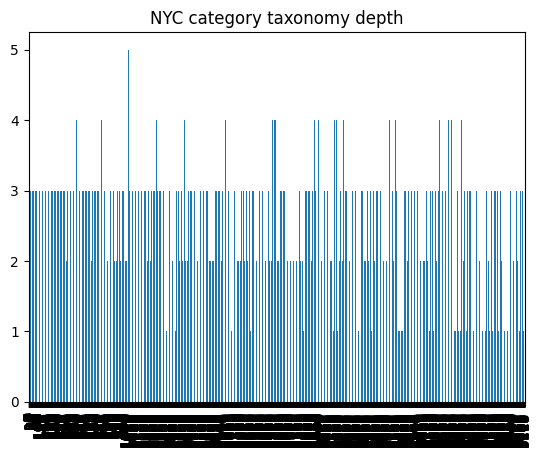

In [22]:
# Category taxonomy depth (from the '>' separated 'category' column)
_cat_depth = poi_meta['category'].dropna().str.count('>') + 1
print("category taxonomy depth value counts:")
print(_cat_depth.value_counts().sort_index())
_cat_depth.plot(kind='bar', title=f'{DATASET} category taxonomy depth')


train_df visits-per-POI describe():
count    5120.000000
mean       22.995313
std        30.342744
min         1.000000
25%        10.000000
50%        15.000000
75%        26.000000
max       918.000000
Name: count, dtype: float64

train_df visits-per-user describe():
count    1073.000000
mean      109.726002
std       129.285145
min        24.000000
25%        54.000000
50%        75.000000
75%       115.000000
max      2012.000000
dtype: float64


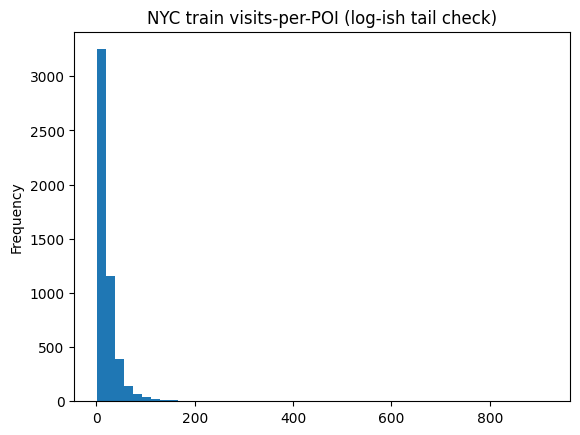

In [23]:
# Visit-count distribution per POI/user, post-filtering (use train_df -- that's what the
# MIN_VENUE_VISITS / MIN_USER_VISITS thresholds were applied to)
if train_df is not None:
    _visits_per_poi  = train_df['venue_id'].value_counts()
    _visits_per_user = train_df.groupby('user_id').size()
    print("train_df visits-per-POI describe():")
    print(_visits_per_poi.describe())
    print("\ntrain_df visits-per-user describe():")
    print(_visits_per_user.describe())
    _visits_per_poi.plot(kind='hist', bins=50, title=f'{DATASET} train visits-per-POI (log-ish tail check)')
else:
    print("Skipped: train_df not loaded for this dataset")
